# ECON4002 — Week 12: Decision Making Under Uncertainty: R Code Implementations

**University of Western Australia**  
*R implementations for expected utility, certainty equivalents, risk premiums, insurance demand, and value of information*

---

## Key Formulae

Expected utility: $EU = \sum_i p_i u(v_i)$. Risk premium: $u(EV - \rho) = EU$

---

> **How to use:** Run each cell in order. Modify the parameters and re-run to explore the economics.

In [ ]:
# ECON4002 Week 12 — R Setup
# Run this cell first to configure options
options(scipen = 6, digits = 4)
cat('Week 12: Decision Making Under Uncertainty: R Code Implementations — ready!\n')

Week 12: Decision Making Under Uncertainty: R Code Implementations — ready!


## Expected Utility

### W12-CS01 — Expected Value Calculator

> **Note:** Basic expected value calculation. Validates that probabilities sum to 1.

In [ ]:
expected_value <- function(outcomes, probs) {
  if (abs(sum(probs) - 1) > 1e-6) stop('Probabilities must sum to 1')
  EV <- sum(probs * outcomes)
  cat('E[X] =', paste(probs, '*', outcomes, collapse=' + '), '=', EV, '\n')
  return(EV)
}

# Farmer fertilizer example
EV <- expected_value(outcomes = c(450, 50), probs = c(0.5, 0.5))

### W12-CS02 — Expected Utility Analysis

> **Note:** Complete EU analysis with CE and RP. Requires utility and inverse utility functions.

In [ ]:
eu_analysis <- function(outcomes, probs, u_fn, u_inv) {
  EV <- sum(probs * outcomes)
  utilities <- sapply(outcomes, u_fn)
  EU <- sum(probs * utilities)
  CE <- u_inv(EU)
  RP <- EV - CE
  
  cat('=== Expected Utility Analysis ===\n')
  cat('Outcomes:', outcomes, '\n')
  cat('Probabilities:', probs, '\n')
  cat('Utilities:', round(utilities, 2), '\n')
  cat('EV:', round(EV, 2), '\n')
  cat('EU:', round(EU, 2), '\n')
  cat('CE:', round(CE, 2), '\n')
  cat('RP:', round(RP, 2), '\n')
  
  list(EV = EV, EU = EU, CE = CE, RP = RP)
}

# Square root utility
u_sqrt <- function(x) 10 * sqrt(x)
u_sqrt_inv <- function(u) (u/10)^2

result <- eu_analysis(c(450, 50), c(0.5, 0.5), u_sqrt, u_sqrt_inv)

## Utility Functions

### W12-CS03 — Common Utility Functions Library

> **Note:** Library of common utility functions and their inverses. Use for EU calculations.

In [ ]:
# Square root utility (CRRA, γ = 0.5)
u_sqrt <- function(x, a = 1) a * sqrt(x)
u_sqrt_inv <- function(u, a = 1) (u/a)^2

# Logarithmic utility (CRRA, γ → 0)
u_log <- function(x) log(x)
u_log_inv <- function(u) exp(u)

# Exponential/CARA utility
u_cara <- function(x, a = 0.001) -exp(-a * x)
u_cara_inv <- function(u, a = 0.001) -log(-u) / a

# Power utility (CRRA)
u_power <- function(x, gamma = 0.5) {
  if (gamma == 1) return(log(x))
  x^(1 - gamma) / (1 - gamma)
}
u_power_inv <- function(u, gamma = 0.5) {
  if (gamma == 1) return(exp(u))
  (u * (1 - gamma))^(1/(1 - gamma))
}

# Linear utility (risk neutral)
u_linear <- function(x, a = 1, b = 0) a * x + b
u_linear_inv <- function(u, a = 1, b = 0) (u - b) / a

## Risk Measures

### W12-CS04 — Arrow-Pratt Risk Aversion Measures

> **Note:** Calculates Arrow-Pratt absolute and relative risk aversion numerically.

In [ ]:
# Numerical derivatives
num_deriv <- function(f, x, h = 1e-6) (f(x+h) - f(x-h)) / (2*h)
num_deriv2 <- function(f, x, h = 1e-4) (f(x+h) - 2*f(x) + f(x-h)) / (h^2)

# Arrow-Pratt measures
ara <- function(u_fn, x) {
  u1 <- num_deriv(u_fn, x)
  u2 <- num_deriv2(u_fn, x)
  -u2 / u1
}

rra <- function(u_fn, x) {
  x * ara(u_fn, x)
}

# Example: compare risk aversion across wealth levels
wealth_levels <- c(10000, 50000, 100000, 500000)

cat('\n=== Logarithmic utility: u(x) = ln(x) ===\n')
for (w in wealth_levels) {
  cat(sprintf('W = $%d: ARA = %.6f, RRA = %.2f\n', 
              w, ara(u_log, w), rra(u_log, w)))
}

cat('\n=== CARA utility: u(x) = -exp(-0.0001x) ===\n')
u_cara_ex <- function(x) -exp(-0.0001 * x)
for (w in wealth_levels) {
  cat(sprintf('W = $%d: ARA = %.6f, RRA = %.2f\n', 
              w, ara(u_cara_ex, w), rra(u_cara_ex, w)))
}

## Visualization

### W12-CS05 — Plot Expected Utility Diagram

> **Note:** Creates textbook-style EU diagram with chord, CE, EV, and RP labeled.

In [ ]:
plot_eu_diagram <- function(outcomes, probs, u_fn, title = 'Expected Utility') {
  x_range <- seq(0.1, max(outcomes) * 1.2, length = 300)
  u_vals <- sapply(x_range, u_fn)
  
  EU <- sum(probs * sapply(outcomes, u_fn))
  EV <- sum(probs * outcomes)
  
  # Find CE (numerical search)
  CE <- uniroot(function(x) u_fn(x) - EU, c(0.1, max(outcomes)))$root
  RP <- EV - CE
  
  plot(x_range, u_vals, type = 'l', lwd = 2, col = 'black',
       xlab = 'Outcome ($)', ylab = 'Utility',
       main = title, xlim = c(0, max(x_range)))
  
  # Chord (linear interpolation)
  segments(outcomes[1], u_fn(outcomes[1]),
           outcomes[2], u_fn(outcomes[2]),
           col = 'blue', lwd = 2, lty = 2)
  
  # Mark outcomes
  points(outcomes, sapply(outcomes, u_fn), pch = 19, col = 'red', cex = 1.5)
  text(outcomes, sapply(outcomes, u_fn), 
       labels = paste0('u(', outcomes, ')'), pos = c(2, 4), cex = 0.8)
  
  # EU line
  abline(h = EU, col = 'green', lty = 3, lwd = 1.5)
  text(max(x_range) * 0.9, EU, paste('EU =', round(EU, 1)), pos = 3, col = 'green')
  
  # CE and EV
  abline(v = CE, col = 'orange', lty = 3)
  abline(v = EV, col = 'purple', lty = 3)
  
  # Risk premium bracket
  arrows(CE, EU * 0.5, EV, EU * 0.5, code = 3, length = 0.1, col = 'brown')
  text((CE + EV)/2, EU * 0.45, paste('RP =', round(RP, 0)), col = 'brown')
  
  legend('topleft', 
         c('u(x)', 'Chord', 'EU', 'CE', 'EV'),
         col = c('black', 'blue', 'green', 'orange', 'purple'),
         lty = c(1, 2, 3, 3, 3), lwd = c(2, 2, 1.5, 1, 1))
  
  grid()
  list(EU = EU, CE = CE, EV = EV, RP = RP)
}

# Example
u_sqrt <- function(x) 10 * sqrt(x)
plot_eu_diagram(c(50, 450), c(0.5, 0.5), u_sqrt, 'Fertilizer Decision')

### W12-CS06 — Compare Risk Attitudes

> **Note:** Visual comparison of risk averse, neutral, and loving utility functions.

In [ ]:
compare_risk_attitudes <- function(x_max = 1000) {
  x <- seq(1, x_max, length = 200)
  
  # Normalize utilities to [0, 1] for comparison
  u_averse <- sqrt(x) / sqrt(x_max)
  u_neutral <- x / x_max
  u_loving <- (x / x_max)^2
  
  plot(x, u_neutral, type = 'l', lwd = 2, col = 'green',
       xlab = 'Outcome', ylab = 'Utility (normalized)',
       main = 'Risk Attitudes: Utility Function Shapes')
  lines(x, u_averse, lwd = 2, col = 'blue')
  lines(x, u_loving, lwd = 2, col = 'red')
  
  # Mark a fair gamble
  x_low <- 200; x_high <- 800; p <- 0.5
  EV <- p * x_low + (1-p) * x_high
  
  points(c(x_low, x_high, EV), c(sqrt(x_low)/sqrt(x_max), sqrt(x_high)/sqrt(x_max), 
         (p*sqrt(x_low) + (1-p)*sqrt(x_high))/sqrt(x_max)), 
         pch = 19, col = 'blue')
  
  legend('bottomright', 
         c('Risk Neutral (linear)', 'Risk Averse (concave)', 'Risk Loving (convex)'),
         col = c('green', 'blue', 'red'), lwd = 2)
  grid()
}

compare_risk_attitudes()

## Insurance

### W12-CS07 — Insurance Demand Analysis

> **Note:** Complete insurance demand analysis including fair premium and maximum WTP.

In [ ]:
insurance_analysis <- function(W0, loss, p_loss, u_fn, u_inv, coverage = 'full') {
  # Outcomes without insurance
  W_no_loss <- W0
  W_loss <- W0 - loss
  
  EU_no_ins <- (1 - p_loss) * u_fn(W_no_loss) + p_loss * u_fn(W_loss)
  CE_no_ins <- u_inv(EU_no_ins)
  
  # Fair premium
  P_fair <- p_loss * loss
  
  # With full insurance at fair premium
  W_insured <- W0 - P_fair
  EU_fair_ins <- u_fn(W_insured)
  
  # Maximum premium (solves u(W0 - P_max) = EU_no_ins)
  P_max <- W0 - CE_no_ins
  loading_max <- P_max / P_fair
  
  cat('=== Insurance Analysis ===\n')
  cat('Initial wealth:', W0, '\n')
  cat('Potential loss:', loss, 'with probability', p_loss, '\n')
  cat('\nWithout insurance:\n')
  cat('  EU:', round(EU_no_ins, 4), '\n')
  cat('  CE:', round(CE_no_ins, 2), '\n')
  cat('\nFair premium:', round(P_fair, 2), '\n')
  cat('With fair insurance: EU =', round(EU_fair_ins, 4), '\n')
  cat('\nMax premium willing to pay:', round(P_max, 2), '\n')
  cat('Maximum loading:', round((loading_max - 1) * 100, 1), '% above fair\n')
  cat('Risk premium (welfare gain):', round(P_max - P_fair, 2), '\n')
  
  list(EU_no_ins = EU_no_ins, CE_no_ins = CE_no_ins,
       P_fair = P_fair, P_max = P_max,
       loading_max = loading_max)
}

# Sheep farmer example
insurance_analysis(W0 = 200000, loss = 150000, p_loss = 0.05, u_log, u_log_inv)

### W12-CS08 — Plot Insurance Demand Curve

> **Note:** Visualizes insurance demand as function of premium.

In [ ]:
plot_insurance_demand <- function(W0, loss, p_loss, u_fn, u_inv) {
  # Calculate EU without insurance
  EU_no_ins <- (1 - p_loss) * u_fn(W0) + p_loss * u_fn(W0 - loss)
  CE_no_ins <- u_inv(EU_no_ins)
  
  P_fair <- p_loss * loss
  P_max <- W0 - CE_no_ins
  
  # Premium range
  P_range <- seq(0, P_max * 1.2, length = 100)
  
  # EU with insurance at each premium
  EU_ins <- sapply(P_range, function(P) u_fn(W0 - P))
  
  # Demand: buy if EU_ins >= EU_no_ins
  demand <- ifelse(EU_ins >= EU_no_ins, 1, 0)
  
  par(mfrow = c(1, 2))
  
  # Plot 1: EU comparison
  plot(P_range, EU_ins, type = 'l', lwd = 2, col = 'blue',
       xlab = 'Premium ($)', ylab = 'Expected Utility',
       main = 'EU: Insured vs Uninsured')
  abline(h = EU_no_ins, col = 'red', lty = 2, lwd = 2)
  abline(v = P_max, col = 'orange', lty = 3)
  abline(v = P_fair, col = 'green', lty = 3)
  legend('topright', c('EU(insured)', 'EU(uninsured)', 'Max P', 'Fair P'),
         col = c('blue', 'red', 'orange', 'green'), lty = c(1, 2, 3, 3), lwd = 2)
  
  # Plot 2: Demand curve (step function)
  plot(P_range, demand, type = 's', lwd = 2, col = 'darkgreen',
       xlab = 'Premium ($)', ylab = 'Insurance Purchased (0/1)',
       main = 'Insurance Demand', ylim = c(-0.1, 1.1))
  abline(v = P_max, col = 'orange', lty = 2)
  text(P_max, 0.5, paste('Max P =', round(P_max, 0)), pos = 2)
  
  par(mfrow = c(1, 1))
  list(P_fair = P_fair, P_max = P_max)
}

plot_insurance_demand(200000, 150000, 0.05, u_log, u_log_inv)

## Value Of Info

### W12-CS09 — Value of Perfect Information

> **Note:** Calculates VPI by comparing optimal decisions with/without state information.

In [ ]:
value_of_info <- function(states, probs, actions, payoffs, u_fn, u_inv) {
  # payoffs: matrix[states, actions]
  n_states <- length(states)
  n_actions <- length(actions)
  
  # 1. Without information: EU for each action
  EU_actions <- numeric(n_actions)
  for (a in 1:n_actions) {
    EU_actions[a] <- sum(probs * sapply(payoffs[, a], u_fn))
  }
  
  best_action_no_info <- which.max(EU_actions)
  EU_no_info <- max(EU_actions)
  CE_no_info <- u_inv(EU_no_info)
  
  # 2. With perfect information: optimal action in each state
  EU_per_state <- numeric(n_states)
  optimal_actions <- character(n_states)
  for (s in 1:n_states) {
    utilities <- sapply(payoffs[s, ], u_fn)
    best_a <- which.max(utilities)
    EU_per_state[s] <- utilities[best_a]
    optimal_actions[s] <- actions[best_a]
  }
  
  EU_with_info <- sum(probs * EU_per_state)
  CE_with_info <- u_inv(EU_with_info)
  
  VPI <- CE_with_info - CE_no_info
  
  cat('=== Value of Perfect Information ===\n')
  cat('\nWithout info: Best action =', actions[best_action_no_info], '\n')
  cat('  EU =', round(EU_no_info, 2), ', CE =', round(CE_no_info, 2), '\n')
  cat('\nWith perfect info:\n')
  for (s in 1:n_states) {
    cat('  If', states[s], ': choose', optimal_actions[s], '\n')
  }
  cat('  EU =', round(EU_with_info, 2), ', CE =', round(CE_with_info, 2), '\n')
  cat('\nValue of Perfect Information: $', round(VPI, 2), '\n')
  
  list(VPI = VPI, CE_no_info = CE_no_info, CE_with_info = CE_with_info)
}

# Frost protection example
states <- c('Frost', 'No Frost')
probs <- c(0.2, 0.8)
actions <- c('Protect', 'No Protect')
# payoffs[state, action]: wealth outcomes
payoffs <- matrix(c(
  95000, 60000,    # Frost: protect vs no protect
  95000, 100000    # No Frost: protect vs no protect
), nrow = 2, byrow = TRUE)

value_of_info(states, probs, actions, payoffs, u_sqrt, u_sqrt_inv)

### W12-CS10 — Value of Imperfect Information with Bayes

> **Note:** Calculates value of imperfect information using Bayesian updating.

In [ ]:
value_imperfect_info <- function(prior_probs, signal_accuracy, payoffs, actions, u_fn, u_inv) {
  # signal_accuracy: matrix[true_state, signal]
  # e.g., signal_accuracy[1,1] = P(signal_frost | frost)
  
  n_states <- 2  # Simplified for binary case
  n_signals <- 2
  
  # Marginal probability of each signal
  P_signal <- colSums(signal_accuracy * prior_probs)
  
  # Posterior probabilities: P(state | signal) using Bayes
  posterior <- matrix(0, n_states, n_signals)
  for (sig in 1:n_signals) {
    for (s in 1:n_states) {
      posterior[s, sig] <- signal_accuracy[s, sig] * prior_probs[s] / P_signal[sig]
    }
  }
  
  cat('Signal probabilities:', round(P_signal, 3), '\n')
  cat('Posterior P(frost|signal):', round(posterior[1,], 3), '\n')
  
  # Optimal action given each signal
  EU_given_signal <- matrix(0, n_signals, length(actions))
  for (sig in 1:n_signals) {
    for (a in 1:length(actions)) {
      EU_given_signal[sig, a] <- sum(posterior[, sig] * sapply(payoffs[, a], u_fn))
    }
  }
  
  best_action_signal <- apply(EU_given_signal, 1, which.max)
  EU_best_signal <- apply(EU_given_signal, 1, max)
  
  # Expected EU with imperfect info
  EU_imperfect <- sum(P_signal * EU_best_signal)
  CE_imperfect <- u_inv(EU_imperfect)
  
  cat('\nOptimal actions given signals:', actions[best_action_signal], '\n')
  cat('EU with imperfect info:', round(EU_imperfect, 2), '\n')
  cat('CE with imperfect info:', round(CE_imperfect, 2), '\n')
  
  list(EU = EU_imperfect, CE = CE_imperfect, 
       P_signal = P_signal, posterior = posterior)
}

# Imperfect frost forecast
prior_probs <- c(0.2, 0.8)  # P(frost), P(no frost)
signal_accuracy <- matrix(c(
  0.80, 0.20,  # P(predict frost | frost), P(predict no frost | frost)
  0.10, 0.90   # P(predict frost | no frost), P(predict no frost | no frost)
), nrow = 2, byrow = TRUE)

payoffs <- matrix(c(95000, 60000, 95000, 100000), nrow = 2, byrow = TRUE)

result <- value_imperfect_info(prior_probs, signal_accuracy, payoffs, 
                               c('Protect', 'No Protect'), u_sqrt, u_sqrt_inv)

## Portfolio

### W12-CS11 — Mean-Variance Portfolio Optimization

> **Note:** Two-asset portfolio optimization using mean-variance framework.

In [ ]:
mv_portfolio <- function(returns, std_devs, corr, risk_aversion, total_area = 100) {
  # Two-asset portfolio optimization
  # returns: expected return per unit
  # std_devs: standard deviation per unit
  # corr: correlation between assets
  
  E1 <- returns[1]; E2 <- returns[2]
  s1 <- std_devs[1]; s2 <- std_devs[2]
  
  # Grid search for optimal allocation
  w_range <- seq(0, total_area, by = 1)
  results <- data.frame(w1 = w_range)
  results$w2 <- total_area - w_range
  
  results$E_R <- w_range * E1 + (total_area - w_range) * E2
  results$Var_R <- w_range^2 * s1^2 + (total_area - w_range)^2 * s2^2 + 
                   2 * w_range * (total_area - w_range) * corr * s1 * s2
  results$U <- results$E_R - (risk_aversion / 2) * results$Var_R
  
  optimal <- results[which.max(results$U), ]
  
  cat('=== Mean-Variance Portfolio ===\n')
  cat('Asset 1: E =', E1, ', σ =', s1, '\n')
  cat('Asset 2: E =', E2, ', σ =', s2, '\n')
  cat('Correlation:', corr, '\n')
  cat('Risk aversion A:', risk_aversion, '\n')
  cat('\nOptimal allocation:\n')
  cat('  Asset 1:', optimal$w1, 'units\n')
  cat('  Asset 2:', optimal$w2, 'units\n')
  cat('  E[R]:', round(optimal$E_R, 0), '\n')
  cat('  Var[R]:', round(optimal$Var_R, 0), '\n')
  cat('  Utility:', round(optimal$U, 2), '\n')
  
  # Plot efficient frontier
  plot(sqrt(results$Var_R), results$E_R, type = 'l', lwd = 2, col = 'blue',
       xlab = 'Portfolio Std Dev', ylab = 'Expected Return',
       main = 'Portfolio Frontier')
  points(sqrt(optimal$Var_R), optimal$E_R, pch = 19, col = 'red', cex = 2)
  
  list(optimal = optimal, all_portfolios = results)
}

mv_portfolio(returns = c(400, 500), std_devs = c(150, 300), 
             corr = 0.2, risk_aversion = 0.002)

## Complete

### W12-CS12 — Complete Uncertainty Toolkit

> **Note:** Unified toolkit for all uncertainty calculations with specified utility function.

In [ ]:
# Source all utility functions first
u_sqrt <- function(x) sqrt(x)
u_sqrt_inv <- function(u) u^2
u_log <- function(x) log(x)
u_log_inv <- function(u) exp(u)

# Unified toolkit
uncertainty_toolkit <- function(u_fn = u_sqrt, u_inv = u_sqrt_inv) {
  list(
    eu_analysis = function(outcomes, probs) {
      eu_analysis(outcomes, probs, u_fn, u_inv)
    },
    
    plot_eu = function(outcomes, probs, title = 'EU Analysis') {
      plot_eu_diagram(outcomes, probs, u_fn, title)
    },
    
    insurance = function(W0, loss, p_loss) {
      insurance_analysis(W0, loss, p_loss, u_fn, u_inv)
    },
    
    vpi = function(states, probs, actions, payoffs) {
      value_of_info(states, probs, actions, payoffs, u_fn, u_inv)
    },
    
    risk_aversion = function(x) {
      list(ARA = ara(u_fn, x), RRA = rra(u_fn, x))
    }
  )
}

# Usage
toolkit <- uncertainty_toolkit(u_log, u_log_inv)
toolkit$eu_analysis(c(50, 450), c(0.5, 0.5))
toolkit$insurance(100000, 50000, 0.1)

## Viewer Test: HTML Table Output

The cell below has a pre-rendered HTML table (simulating a data frame `print()`). This tests the notebook viewer's HTML output rendering.

In [ ]:
# Data frame display — output pre-rendered for viewer testing
farm_data <- data.frame(
  crop    = c('wheat', 'corn', 'soybean'),
  yield   = c(45, 180, 50),
  price   = c(7.50, 4.50, 13.00),
  revenue = c(337.50, 810.00, 650.00)
)
farm_data

,crop,yield,price,revenue
0,wheat,45,7.50,337.50
1,corn,180,4.50,810.00
2,soybean,50,13.00,650.00


## Viewer Test: Image Output

The cell below has a pre-rendered supply & demand plot. This tests the notebook viewer's image rendering.

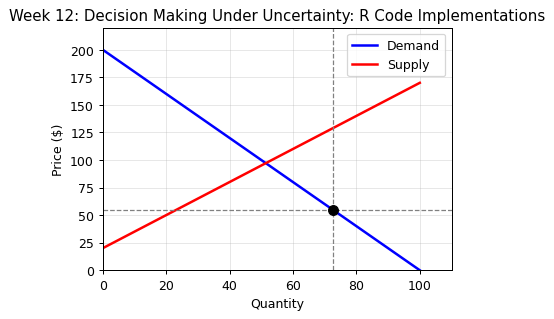

In [ ]:
# Supply & demand plot — output pre-rendered for viewer testing
P_range <- seq(0, 100, by = 0.5)
Qd <- 200 - 2 * P_range
Qs <- 20 + 1.5 * P_range
plot(Qd, P_range, type='l', col='blue', lwd=2,
     xlab='Quantity', ylab='Price', main='Supply & Demand')
lines(Qs, P_range, col='red', lwd=2)
legend('topright', c('Demand','Supply'), col=c('blue','red'), lty=1)

## Viewer Test: Empty Cell

The cell below is intentionally empty — the viewer should skip it gracefully.

## Common Patterns

**Expected Utility**

```r
EU <- sum(probs * sapply(outcomes, u_fn))
```

**Certainty Equivalent**

```r
CE <- u_inv(EU)  # where u_inv is the inverse utility function
```

**Risk Premium**

```r
RP <- sum(probs * outcomes) - CE
```

**Fair Insurance Premium**

```r
P_fair <- prob_loss * loss_amount
```

**Maximum Insurance Premium**

```r
P_max <- W0 - u_inv(EU_uninsured)
```

## Debugging Tips

| Error | Cause | Fix |
|-------|-------|-----|
| `Negative utility with sqrt or log` | Attempting sqrt or log of negative number | Ensure all wealth outcomes are positive; check for losses exceeding wealth |
| `CE > EV for risk averse agent` | Wrong utility function or inverse function | Verify u_fn is concave and u_inv is the correct inverse |
| `Probabilities don't sum to 1` | Input error or rounding | Normalize: probs <- probs / sum(probs) |
| `VPI is negative` | Information should never have negative value | Check payoff matrix orientation and calculation logic |